# Linear Regression

We’re using the California Housing dataset, which contains features like average number of rooms and income etc., and our target is to predict the median house value. This dataset is available in a library called sklearn.

##**1. Import libraries**

In [112]:
from sklearn.datasets import fetch_california_housing
# More infos here: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## **2. Load the California housing dataset and performing EDA**

In [113]:
data = fetch_california_housing() # you can use other datasets select from here, https://github.com/scikit-learn/scikit-learn/tree/main/sklearn/datasets
                                  # put fetch for the name (_covtype.py) -> fetch_covtype

In [114]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [115]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [116]:
X = pd.DataFrame(data.data, columns=data.feature_names) #feature matrix
y = data.target #target values - house value

In [117]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [118]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [119]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [120]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

## **3. Train-test split**
    We split our data into 80% for training and 20% for testing. This helps evaluate how well the model performs on unseen data.

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## **4. Create and train the Linear Regression model**

In [122]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [123]:
#What is the model? Weights and bias?
print("Coefficients / Weights:", model.coef_)
print("Intercept/ias:", model.intercept_)

Coefficients / Weights: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept/ias: -37.02327770606409


## **5. Predict on test data**

In [124]:
y_test_pred = model.predict(X_test)

## **6. Evaluate the model**

### **Visualize actual vs predicted**

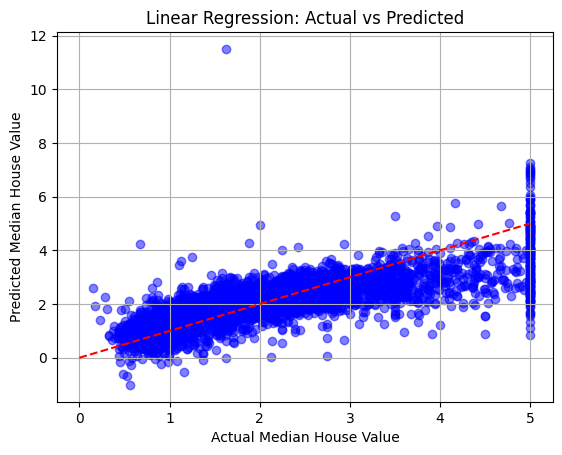

In [125]:
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue')
plt.plot([0, 5], [0, 5], '--', color='red')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

### **Loss and Error**

 For linear Regression, the default loss function = (Actual - Predicted)²

In [127]:
# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({
    'Actual': y_test.round(2),
    'Predicted': y_test_pred.round(2)
})

# Display the top 10 rows
results_df['Error'] = (results_df['Actual'] - results_df['Predicted']).abs().round(2)
results_df.head(10)


,Actual,Predicted,Error
0,0.48,0.72,0.24
1,0.46,1.76,1.30
2,5.00,2.71,2.29
3,2.19,2.84,0.65
4,2.78,2.60,0.18
5,1.59,2.01,0.42
6,1.98,2.65,0.67
7,1.58,2.17,0.59
8,3.40,2.74,0.66
9,4.47,3.92,0.55


### **Cost functions**

**MSE**
The average of all squared losses across the dataset
MSE = (1/n) × Σ (Actual - Predicted)²

**RMSE**
The square root of MSE. It brings the error back to the original unit scale (e.g., in $100,000s for house prices), making it easier to interpret.

**R²**
R² (R-squared score) is a statistical metric that measures how well a regression model's predictions explain the variance of actual data points

R² = 1 → Perfect model

R² = 0 → Model predicts no better than the average

R² < 0 → Model is worse than guessing

In [128]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared Score:", r2)



Mean Squared Error (MSE): 0.5558915986952444
Root Mean Squared Error (RMSE): 0.7455813830127764
R-squared Score: 0.5757877060324508


### **Distribution of Median Income vs. Actual House Value**

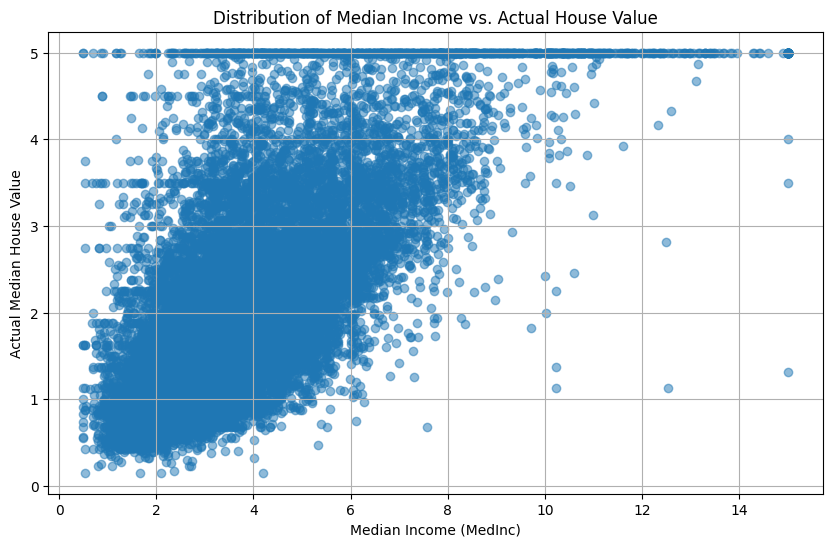

In [126]:
plt.figure(figsize=(10, 6))
plt.scatter(X['MedInc'], y, alpha=0.5)
plt.xlabel('Median Income (MedInc)')
plt.ylabel('Actual Median House Value')
plt.title('Distribution of Median Income vs. Actual House Value')
plt.grid(True)
plt.show()